**1. House Price Prediction System
 Concepts Used:**

*   Linear Regression Model
*   Cost Function (MSE)
*   Ordinary Least Squares (OLS)
*   R-squared & Adjusted R-squared

**Project Overview**

• Build a model that predicts house prices based on features like square footage,
number of bedrooms, location, and age of the house.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('house_data.csv')

# Check for non-numeric columns
non_numeric_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"Non-numeric columns: {non_numeric_columns}")

# Convert categorical columns to numerical using one-hot encoding
if non_numeric_columns:
    df = pd.get_dummies(df, columns=non_numeric_columns, drop_first=True)

# Ensure 'price' column exists
if 'price' not in df.columns:
    raise KeyError("The dataset does not contain a 'price' column. Please check the CSV file.")

# Define features (X) and target (y)
X = df.drop(columns=['price'])  # Features
y = df['price']  # Target variable

# Ensure all feature columns are numeric
if not np.issubdtype(X.dtypes.values[0], np.number):
    raise ValueError("Some features are still non-numeric. Check the dataset preprocessing.")

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model using OLS
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Calculate Adjusted R-squared
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Display results
print(f'Model Evaluation:\nMSE: {mse:.2f}, R-squared: {r2:.2f}, Adjusted R-squared: {adjusted_r2:.2f}')



Non-numeric columns: ['municipality_name', 'object_type_name']
Model Evaluation:
MSE: 149210817251.74, R-squared: 0.49, Adjusted R-squared: 0.09


**2. Salary Prediction System
 Concepts Used:**
* Dependent & Independent Variables
* Regression Line & Coefficients
* Gradient Descent Optimization
* Bias-Variance Tradeoff

**Project Overview:**

• Develop a system that predicts the salary of an employee based on their
experience, education, job role, and location.

Step 2: Loading dataset...
Dataset sample:
   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0

Step 3: Preprocessing data...

Step 4: Applying linear regression...
Model performance:
Mean Squared Error: 49830096.85590839
R-squared: 0.9024461774180497

Step 5: Visualizing regression results...


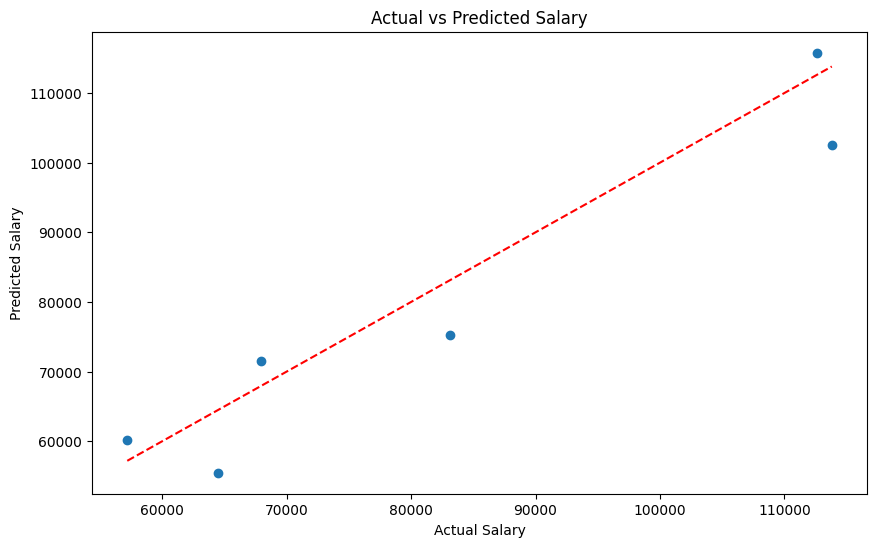


Step 6: Creating Streamlit web app...

Step 7 & 8: App creation complete!

Run the following command to start the Streamlit app:
streamlit run app.py


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import streamlit as st
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os

# Step 2: Load dataset
print("Step 2: Loading dataset...")
df = pd.read_csv('salary_data.csv')
print("Dataset sample:")
print(df.head())

# Step 3: Preprocess data and define variables
print("\nStep 3: Preprocessing data...")
df.dropna(inplace=True)

# Identify categorical columns
categorical_columns = ['degree', 'job_role', 'location']
existing_categorical_columns = [col for col in categorical_columns if col in df.columns]

# Apply one-hot encoding if categorical columns exist
if existing_categorical_columns:
    df = pd.get_dummies(df, columns=existing_categorical_columns, drop_first=True)

# Define features and target variable
if 'Salary' in df.columns:
    X = df.drop(columns=['Salary'])
    y = df['Salary']

    # Step 4: Split dataset and apply linear regression
    print("\nStep 4: Applying linear regression...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train the model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Evaluate model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'Model performance:')
    print(f'Mean Squared Error: {mse}')
    print(f'R-squared: {r2}')

    # Step 5: Visualize regression results
    print("\nStep 5: Visualizing regression results...")
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
    plt.xlabel('Actual Salary')
    plt.ylabel('Predicted Salary')
    plt.title('Actual vs Predicted Salary')
    plt.show()

    # Step 6: Create Streamlit web app
    print("\nStep 6: Creating Streamlit web app...")

    # Save the model and features for the app to use
    joblib.dump(model, 'salary_model.joblib')
    joblib.dump(list(X.columns), 'features.joblib')

    # Create the Streamlit app file
    with open("app.py", "w") as f:
        f.write('''
import streamlit as st
import pandas as pd
import joblib

# Load the model and features
try:
    model = joblib.load('salary_model.joblib')
    features = joblib.load('features.joblib')

    st.title("Salary Prediction System")
    st.write("Enter the details to predict salary.")

    # Create input fields for user data
    input_data = {}
    for col in features:
        input_data[col] = st.number_input(f"Enter {col}", min_value=0.0, step=0.1)

    # Convert input into DataFrame
    input_df = pd.DataFrame([input_data])

    # Predict salary
    if st.button("Predict Salary"):
        prediction = model.predict(input_df)
        st.success(f"Predicted Salary: ${prediction[0]:,.2f}")

except Exception as e:
    st.error(f"An error occurred: {e}")
    st.write("Please make sure the model files exist and are correctly formatted.")
''')

    # Step 7 & 8: Compile, run and show output
    print("\nStep 7 & 8: App creation complete!")
    print("\nRun the following command to start the Streamlit app:")
    print("streamlit run app.py")


else:
    print("Error: The 'Salary' column is missing from the dataset.")

In [ ]:
!streamlit run app.py &>/content/logs.txt & npx localtunnel --port 8501 & curl ipv4.icanhazip.com

34.23.195.37
⠙your url is: https://evil-banks-stare.loca.lt


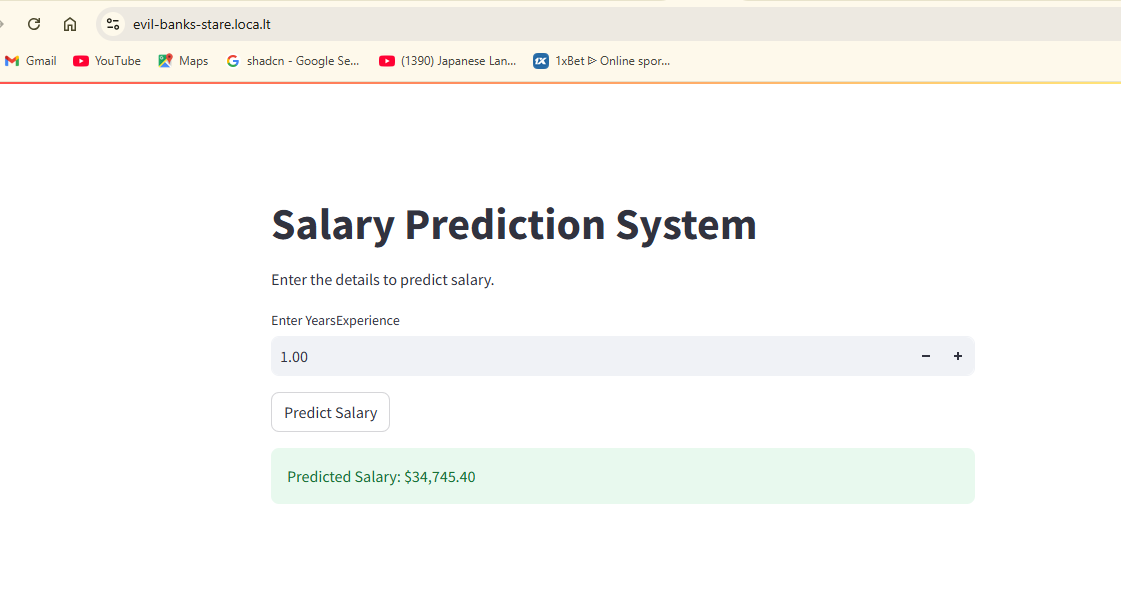

**3.Stock Price Trend Prediction
 Concepts Used:**
* Equation of a Straight Line
* Ordinary Least Squares (OLS)
* R-squared Evaluation

**Project Overview:**
 Predict the future closing price of a stock based on past stock prices, volume,
and market trends

In [ ]:

# Step 2: Create the stock prediction app file
%%writefile stock_prediction_app.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import streamlit as st

# Fetch stock data
def get_stock_data(ticker):
    stock = yf.Ticker(ticker)
    df = stock.history(period='5y')
    df = df[['Close', 'Volume']].dropna()
    df['Day'] = np.arange(len(df))
    return df

# Load dataset
ticker = 'AAPL'  # Example stock symbol
df = get_stock_data(ticker)

# Define features and target variable
X = df[['Day', 'Volume']]
y = df['Close']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse}, R-squared: {r2}')

# Calculate adjusted R-squared
n = len(X_test)  # Number of observations
p = 2  # Number of predictors (Day and Volume)
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print(f'Adjusted R-squared: {adjusted_r2}')

# Streamlit app for visualization
st.title('Stock Price Trend Prediction')
st.write(f'Stock: {ticker}')

# Display metrics
st.subheader('Model Performance')
col1, col2, col3 = st.columns(3)
with col1:
    st.metric("MSE", f"{mse:.4f}")
with col2:
    st.metric("R²", f"{r2:.4f}")
with col3:
    st.metric("Adjusted R²", f"{adjusted_r2:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df['Day'], df['Close'], label='Actual Prices', color='blue')
ax.scatter(X_test['Day'], y_pred, label='Predicted Prices', color='red')
ax.set_xlabel('Day')
ax.set_ylabel('Stock Price')
ax.legend()
st.pyplot(fig)

# Prediction function
def predict_stock_price(day, volume):
    input_data = np.array([day, volume]).reshape(1, -1)
    return model.predict(input_data)[0]

# User input for prediction
st.sidebar.header('Predict Future Stock Price')
day = st.sidebar.number_input('Enter Future Day:',
                             min_value=int(df['Day'].min()),
                             max_value=int(df['Day'].max())+30)
volume = st.sidebar.number_input('Enter Expected Volume:',
                                min_value=int(df['Volume'].min()),
                                max_value=int(df['Volume'].max()))

if st.sidebar.button('Predict'):
    prediction = predict_stock_price(day, volume)
    st.sidebar.write(f'Predicted Stock Price: ${prediction:.2f}')




Overwriting stock_prediction_app.py


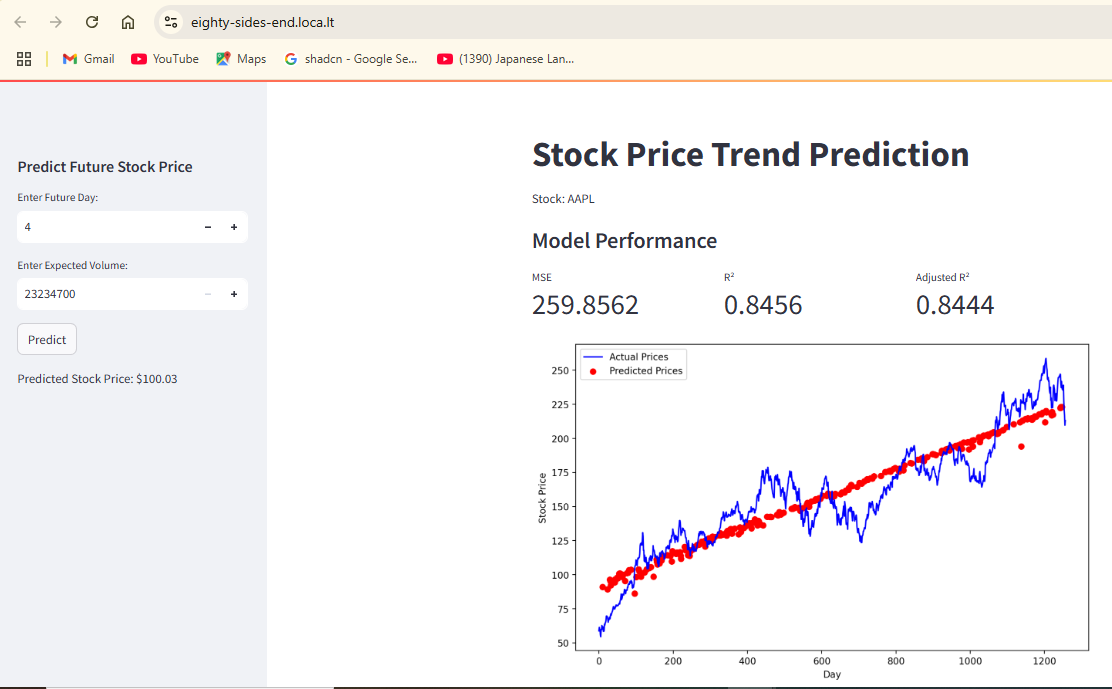

**4.Customer Churn Prediction for a Subscription Service
 Concepts Used:**
* Cost Function (MSE)
* Bias-Variance Tradeoff
* Regression Coefficients

**Project Overview**
 Predict whether a customer will continue their subscription or churn based on
factors like engagement, billing issues, and customer support interactions.

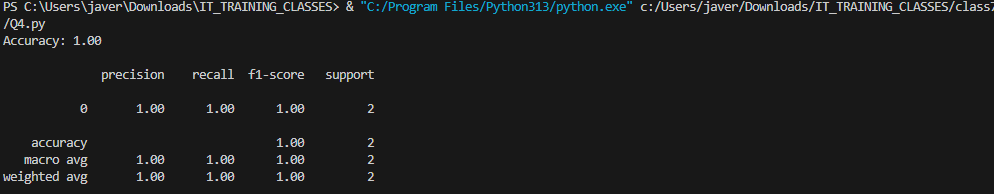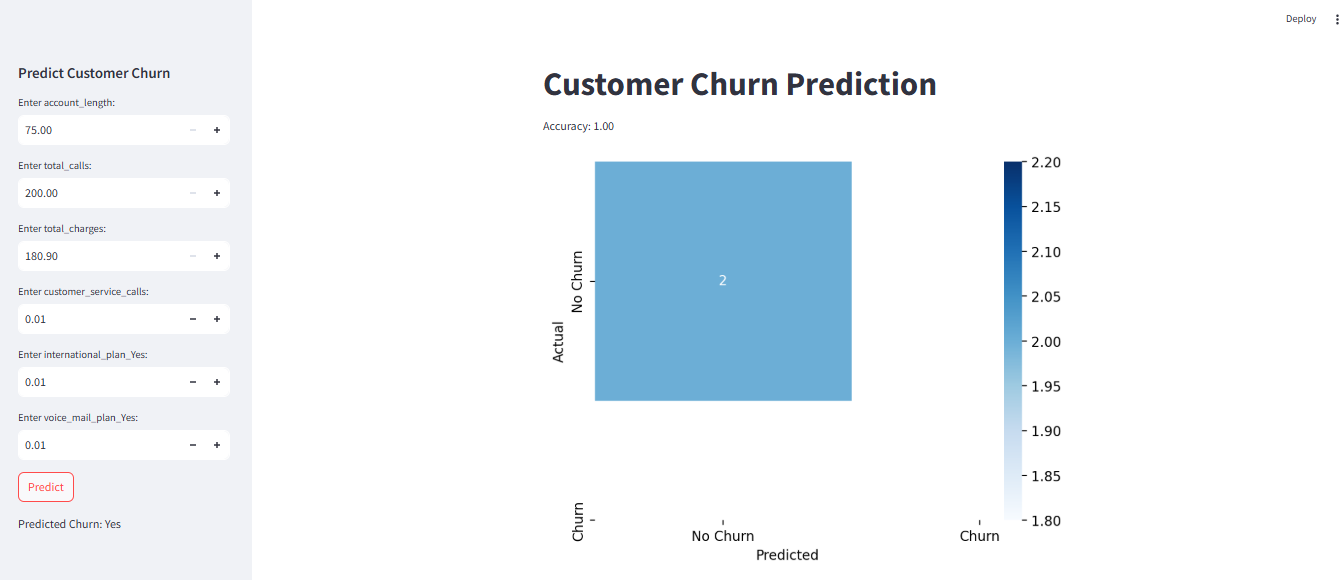

**5. Energy Consumption Prediction**

 **Concepts Used:**
*   Mean Squared Error (MSE)
*   Gradient Descent Optimization
*   Bias-Variance Tradeoff

 **Project Overview:**
*   Predict energy consumption of households based on temperature, appliance
usage, and seasonal variations.



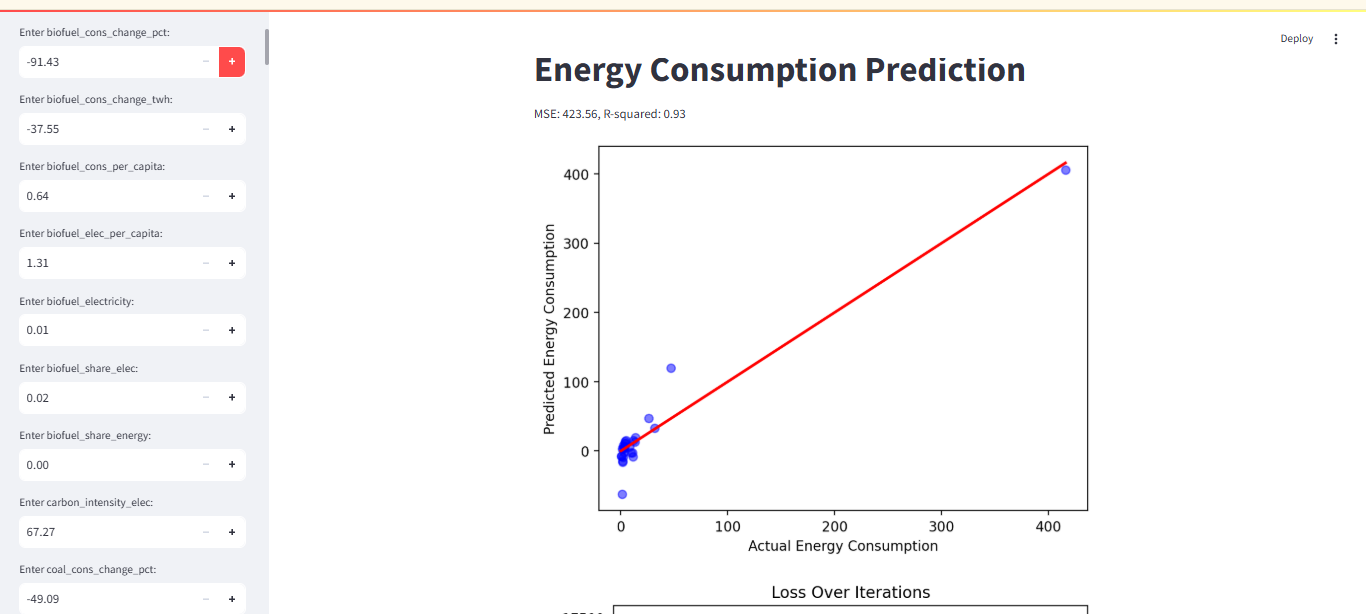